In [234]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [235]:
h='/content/sample_data/Titanic-Dataset.csv'
df=pd.read_csv(h)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [236]:
df.shape

(891, 12)

In [237]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [238]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [239]:
numeric=['Pclass', 'Age','SibSp', 'Parch', 'Fare']
cat=['Name','Sex','Ticket','Cabin','Embarked']
target='Survived'

In [240]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


array([[<Axes: title={'center': 'Pclass'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>],
       [<Axes: title={'center': 'Fare'}>, <Axes: >]], dtype=object)

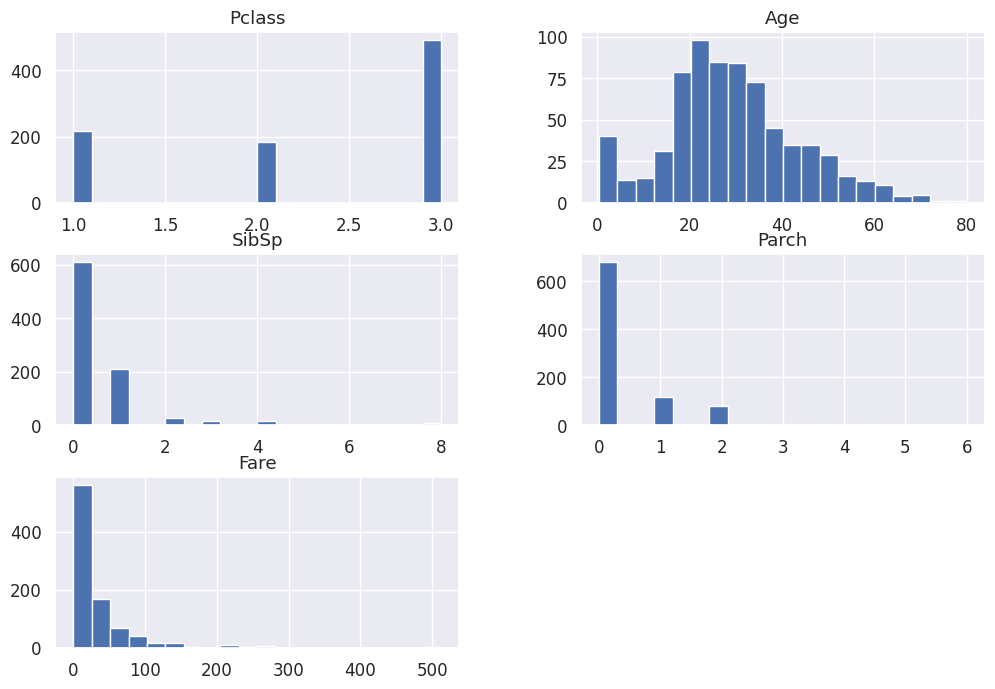

In [241]:
plt.style.use("default")
sns.set(font_scale=1.1)

df[numeric].hist(bins=20, figsize=(12,8))

In [242]:
# numeric.remove('Age')
# print(numeric)

<Axes: >

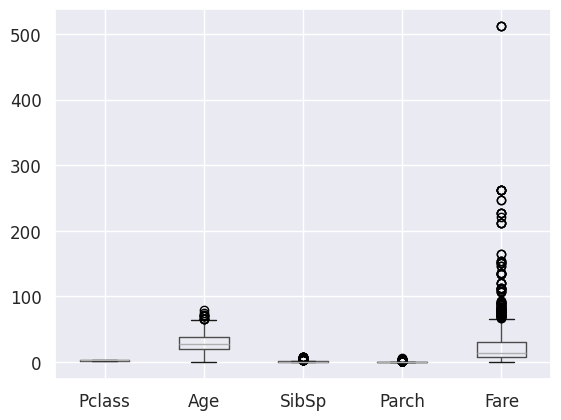

In [243]:
df[numeric].boxplot()

<Axes: xlabel='Survived', ylabel='count'>

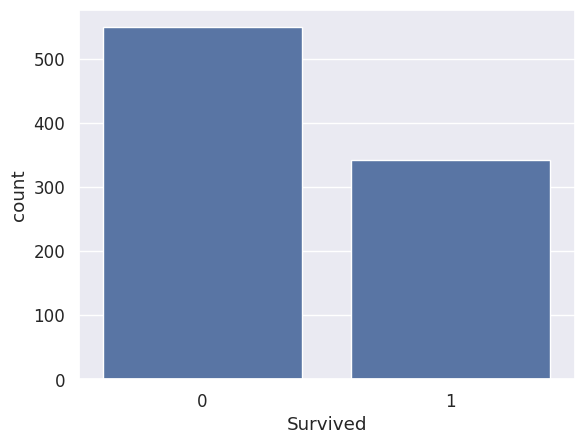

In [244]:
sns.countplot(x=df[target])

/tmp/ipykernel_2570/3297735665.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


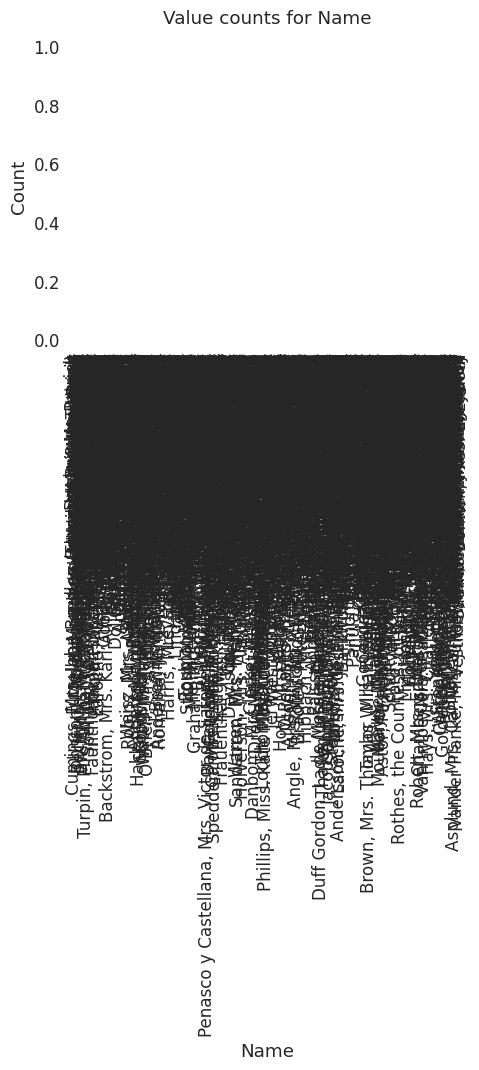

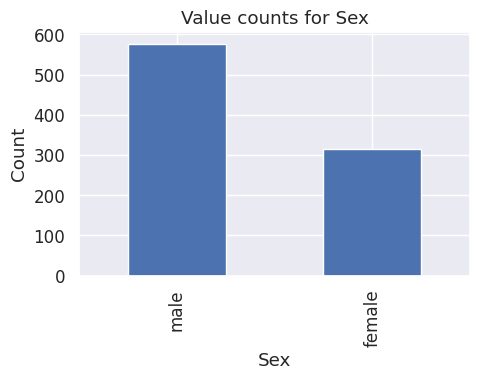

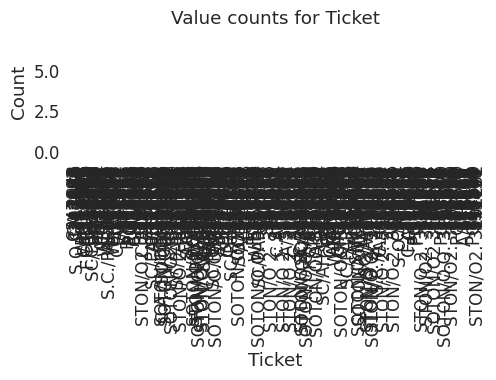

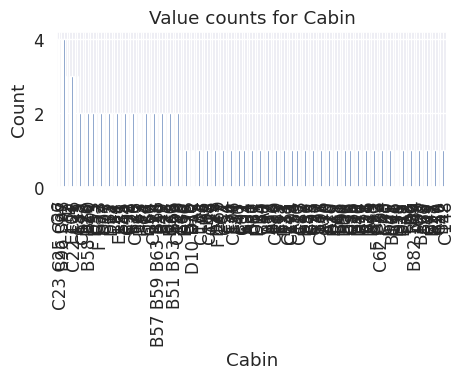

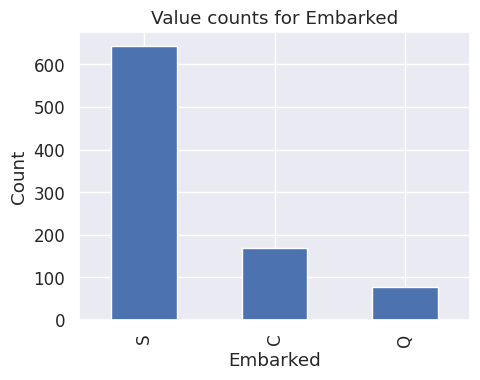

In [245]:
#Categorical Feature Exploration
for c in cat:
  plt.figure(figsize=(5,4))
  df[c].value_counts().plot(kind="bar")
  plt.title(f"Value counts for {c}")
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()

In [246]:
cat = [col for col in cat if col not in ['Ticket', 'Cabin', 'Name']]

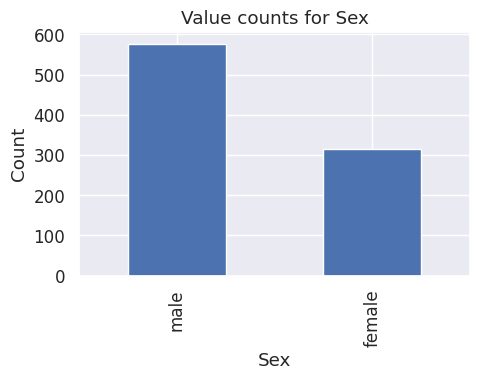

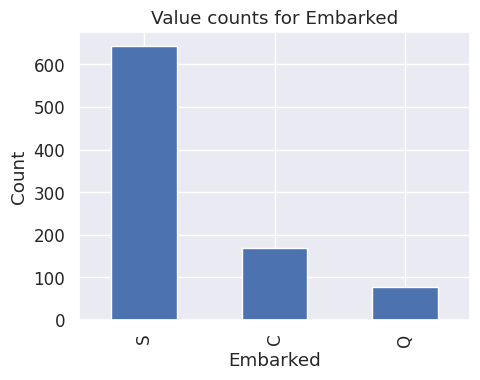

In [247]:
for c in cat:
  plt.figure(figsize=(5,4))
  df[c].value_counts().plot(kind="bar")
  plt.title(f"Value counts for {c}")
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()


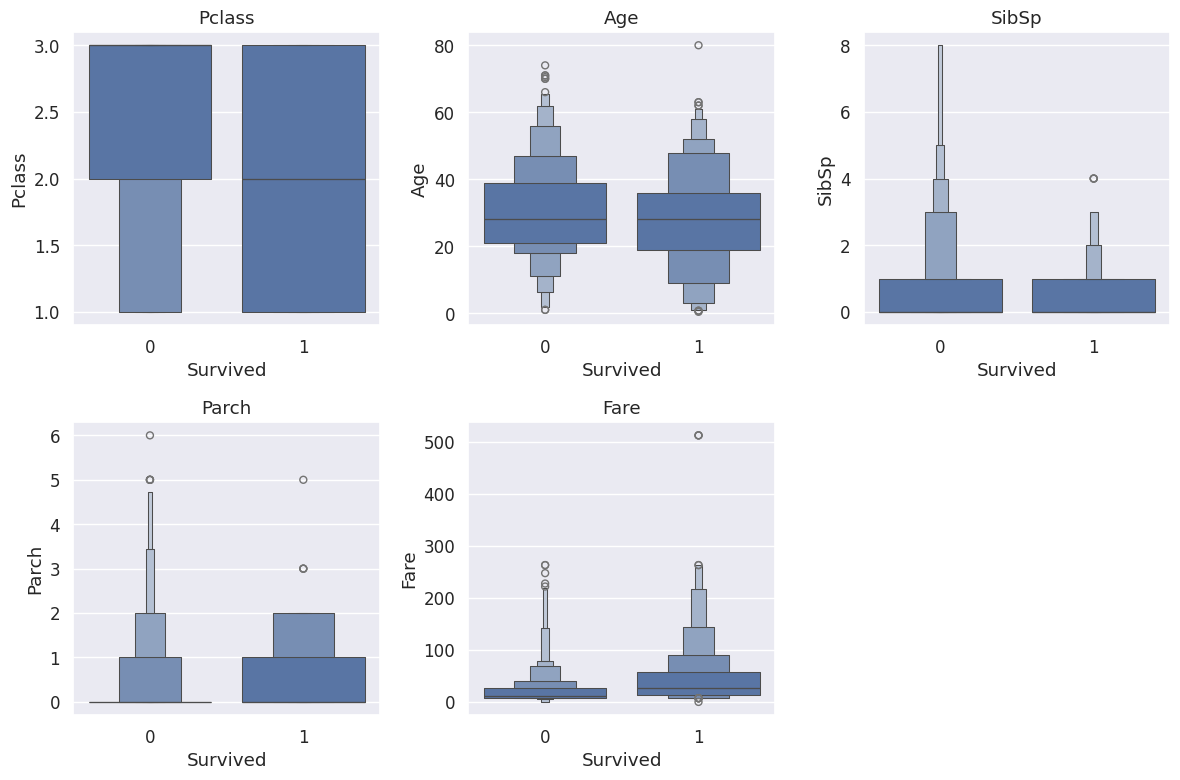

In [248]:
#relationship with numeric and target
plt.figure(figsize=(12,8))
for c,col in enumerate(numeric,1):
  plt.subplot(2,3,c)
  sns.boxenplot(x=df[target], y=df[col])
  plt.title(col)
plt.tight_layout()
plt.show()

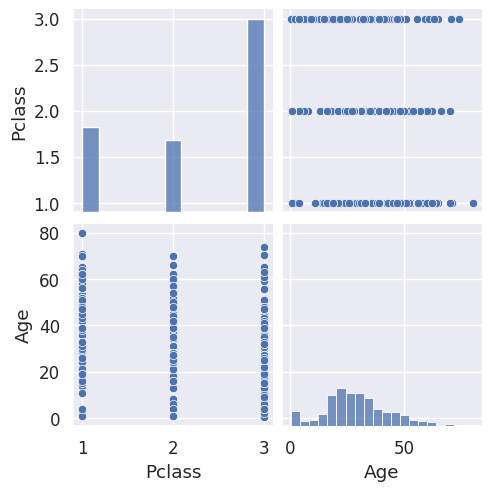

In [249]:
sns.pairplot(df[['Pclass', 'Age']])

<Axes: >

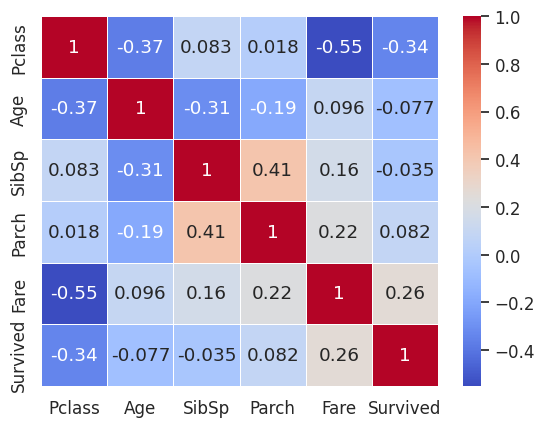

In [250]:
corr_matrix=df[numeric+ [target]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',linewidths=0.5)

Sex


Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


Embarked


Survived,0,1
Embarked,,
C,0.446429,0.553571
Q,0.610390,0.389610
S,0.663043,0.336957


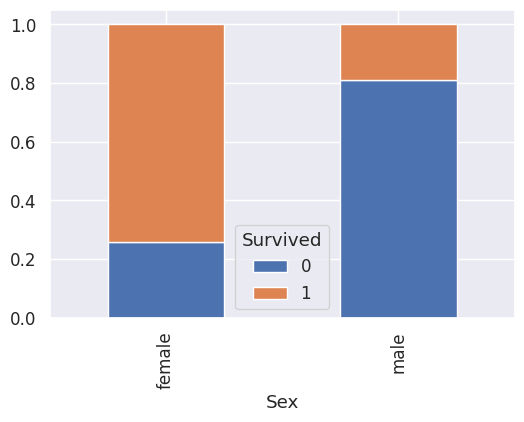

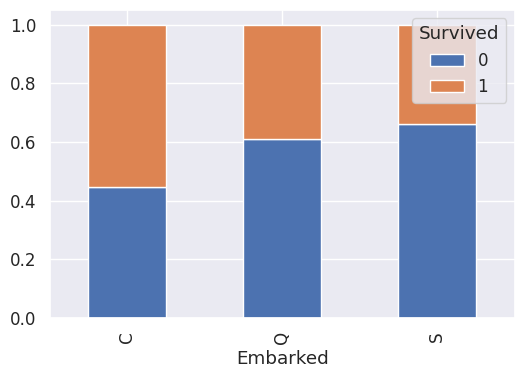

In [251]:
for c in cat:
  ct=pd.crosstab(df[c],df[target], normalize='index')
  print(c)
  display(ct)

  ct.plot(kind="bar", stacked=True, figsize=(6,4))


In [252]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [253]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [254]:
# #missing value handale
# #cabin more than 50 value missing so drop
# df=df.drop(columns=['Cabin'])
# #handale age this is risht sekew
# age_m=df['Age'].median()
# df['Age']=df['Age'].fillna(age_m)

In [255]:
df=df.drop(columns=['Cabin'])

In [256]:
age_m=df['Age'].median()
df['Age']=df['Age'].fillna(age_m)


In [257]:
Embarked_m=df['Embarked'].mode()[0]
df['Embarked']=df['Embarked'].fillna(Embarked_m)

In [258]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [259]:
cat

['Sex', 'Embarked']

In [260]:
numeric

['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

In [261]:
df[cat].nunique()

,0
Sex,2
Embarked,3


In [262]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
df['Sex']=le.fit_transform(df['Sex'])

In [263]:
cat=['Embarked']
df_encoded=pd.get_dummies(
    df,
    columns=cat,
    dtype=int
)

In [264]:
df_encoded.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,0,0,1
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,0,0,1


In [265]:
df_encoded.drop(columns=['Name', 'Ticket'], inplace=True)

In [266]:
df_encoded.head(3)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,1,22.0,1,0,7.2500,0,0,1
1,2,1,1,0,38.0,1,0,71.2833,1,0,0
2,3,1,3,0,26.0,0,0,7.9250,0,0,1


In [267]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

x=df_encoded.drop(columns=[target])
y=df_encoded[target]


x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.25, random_state=42)


scaler_sd= StandardScaler()
x_train_ss=scaler_sd.fit_transform(x_train)
x_test_ss=scaler_sd.transform(x_test)

x_train_ss_df=pd.DataFrame(x_train_ss, columns=x_train.columns, index=x_train.index)
x_test_ss_df=pd.DataFrame(x_test_ss, columns=x_test.columns, index=x_test.index)

print("\nFirst 5 rows of X_train & X_test (Standard Scaled):")
display(x_train_ss_df.head())
display(x_test_ss_df.head())


First 5 rows of X_train & X_test (Standard Scaled):


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
298,-0.575735,-1.620517,0.722247,-0.087648,-0.467660,-0.468878,-0.032568,-0.460805,-0.308354,0.595793
884,1.696946,0.809349,0.722247,-0.318203,-0.467660,-0.468878,-0.487331,-0.460805,-0.308354,0.595793
247,-0.773529,-0.405584,-1.384569,-0.395055,-0.467660,2.046870,-0.342854,-0.460805,-0.308354,0.595793
478,0.122358,0.809349,0.722247,-0.548758,-0.467660,-0.468878,-0.478201,-0.460805,-0.308354,0.595793
305,-0.548587,-1.620517,0.722247,-2.168793,0.376656,2.046870,2.314937,-0.460805,-0.308354,0.595793


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
709,1.018244,0.809349,0.722247,-0.087648,0.376656,0.788996,-0.328391,2.170116,-0.308354,-1.678435
439,-0.028896,-0.405584,0.722247,0.142907,-0.467660,-0.468878,-0.420425,-0.460805,-0.308354,0.595793
840,1.526301,0.809349,0.722247,-0.702462,-0.467660,-0.468878,-0.470362,-0.460805,-0.308354,0.595793
720,1.060906,-0.405584,-1.384569,-1.778386,-0.467660,0.788996,0.015914,-0.460805,-0.308354,0.595793
39,-1.580214,0.809349,-1.384569,-1.163572,0.376656,-0.468878,-0.406042,2.170116,-0.308354,-1.678435


<Axes: >

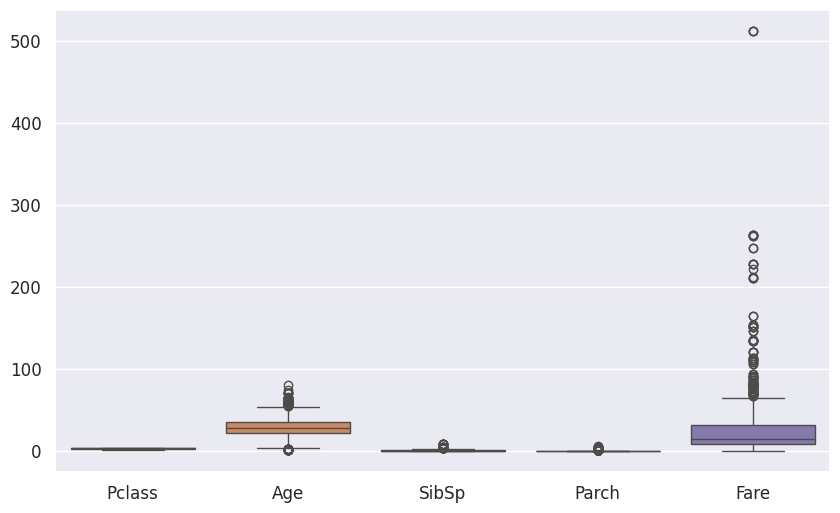

In [268]:
plt.figure(figsize=(10, 6))
sns.boxplot(df_encoded[numeric])

In [269]:
#remoce outlier
col='Fare'
q1=df[col].quantile(0.25)
q3=df[col].quantile(0.75)
iqr=q3-q1

lower_d=q1-1.5*iqr
upper_d=q3+1.5*iqr


outler=df[(df[col]<lower_d) | (df[col]>upper_d)]
print(len(outler))

116


In [270]:
outler_r=df[(df[col]>=lower_d) & (df[col]<=upper_d)]
print(len(outler_r))

775


In [271]:
#
df_cap=df_encoded.copy()
df_cap[col]=df_cap[col].clip(lower_d, upper_d)
print(df_cap)


     PassengerId  Survived  Pclass  Sex   Age  SibSp  Parch     Fare  \
0              1         0       3    1  22.0      1      0   7.2500   
1              2         1       1    0  38.0      1      0  65.6344   
2              3         1       3    0  26.0      0      0   7.9250   
3              4         1       1    0  35.0      1      0  53.1000   
4              5         0       3    1  35.0      0      0   8.0500   
..           ...       ...     ...  ...   ...    ...    ...      ...   
886          887         0       2    1  27.0      0      0  13.0000   
887          888         1       1    0  19.0      0      0  30.0000   
888          889         0       3    0  28.0      1      2  23.4500   
889          890         1       1    1  26.0      0      0  30.0000   
890          891         0       3    1  32.0      0      0   7.7500   

     Embarked_C  Embarked_Q  Embarked_S  
0             0           0           1  
1             1           0           0  
2        

In [272]:
#log
df_log=df_encoded.copy()
df_log[col+'_log']=np.log(df_log[col]+1)
print(df_log)

     PassengerId  Survived  Pclass  Sex   Age  SibSp  Parch     Fare  \
0              1         0       3    1  22.0      1      0   7.2500   
1              2         1       1    0  38.0      1      0  71.2833   
2              3         1       3    0  26.0      0      0   7.9250   
3              4         1       1    0  35.0      1      0  53.1000   
4              5         0       3    1  35.0      0      0   8.0500   
..           ...       ...     ...  ...   ...    ...    ...      ...   
886          887         0       2    1  27.0      0      0  13.0000   
887          888         1       1    0  19.0      0      0  30.0000   
888          889         0       3    0  28.0      1      2  23.4500   
889          890         1       1    1  26.0      0      0  30.0000   
890          891         0       3    1  32.0      0      0   7.7500   

     Embarked_C  Embarked_Q  Embarked_S  Fare_log  
0             0           0           1  2.110213  
1             1           0    

In [273]:
#feature transformation
numeric

['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

In [274]:
from sklearn.preprocessing import PolynomialFeatures
#plolynominal feture
poly_col=['Age','Pclass']
poly= PolynomialFeatures(degree=2, include_bias=False)
poly_feature=poly.fit_transform(df_encoded[poly_col])
poly_feature_names=poly.get_feature_names_out(poly_col)
print(poly_feature_names)

['Age' 'Pclass' 'Age^2' 'Age Pclass' 'Pclass^2']


In [275]:
df['Age']

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,28.0
889,26.0


In [276]:
#bin
df_encoded['Age_bin']=pd.cut(
    df_encoded['Age'],
    bins=[0,20,50,100],
    labels=["Young", "Middle", "Old"]
)
print(df_encoded[['Age','Age_bin']].head(30))

     Age Age_bin
0   22.0  Middle
1   38.0  Middle
2   26.0  Middle
3   35.0  Middle
4   35.0  Middle
5   28.0  Middle
6   54.0     Old
7    2.0   Young
8   27.0  Middle
9   14.0   Young
10   4.0   Young
11  58.0     Old
12  20.0   Young
13  39.0  Middle
14  14.0   Young
15  55.0     Old
16   2.0   Young
17  28.0  Middle
18  31.0  Middle
19  28.0  Middle
20  35.0  Middle
21  34.0  Middle
22  15.0   Young
23  28.0  Middle
24   8.0   Young
25  38.0  Middle
26  28.0  Middle
27  19.0   Young
28  28.0  Middle
29  28.0  Middle


In [277]:
#domain driven
df_encoded['Fare']

,Fare
0,7.2500
1,71.2833
2,7.9250
3,53.1000
4,8.0500
...,...
886,13.0000
887,30.0000
888,23.4500
889,30.0000


In [278]:
def price_range(fare):
  if fare<100:
    return 'low range'

  elif fare>100:
    return 'High Range'

df_encoded['Fare_Range']=df_encoded['Fare'].apply(price_range)
df_encoded.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Age_bin,Fare_Range
0,1,0,3,1,22.0,1,0,7.2500,0,0,1,Middle,low range
1,2,1,1,0,38.0,1,0,71.2833,1,0,0,Middle,low range
2,3,1,3,0,26.0,0,0,7.9250,0,0,1,Middle,low range
3,4,1,1,0,35.0,1,0,53.1000,0,0,1,Middle,low range
4,5,0,3,1,35.0,0,0,8.0500,0,0,1,Middle,low range


In [279]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression , LogisticRegression
from sklearn.preprocessing import  OneHotEncoder, StandardScaler


#newmeric pipeline
num_pipeline=Pipeline([
    ('num', StandardScaler())
])

#cat pipeline
cat_pipelilne=Pipeline([
    ('cat',OneHotEncoder())
])

#both
both_pipeline= ColumnTransformer([
    ('num',num_pipeline,numeric),
    ('cat',cat_pipelilne,cat)
])

#use full pipeline with
clf=Pipeline([
    ('prep',both_pipeline),
    ('model',LogisticRegression(max_iter=1000))
])


In [280]:
x=df.drop(columns=[target])
y=df[target]

x_train_p, x_test_p, y_train_p, y_test_p= train_test_split(x,y, test_size=0.25, random_state=42)

#fit pipeline
clf.fit(x_train_p,  y_train_p)


from sklearn.metrics import accuracy_score
y_pred_p=clf.predict(x_test_p)
acc=accuracy_score(y_test_p, y_pred_p)
print("Logistic Regression with preprocessing pipeline: ", acc)

Logistic Regression with preprocessing pipeline:  0.7309417040358744
